In [1]:
pip install openeo rioxarray matplotlib pyproj python-dateutil

In [2]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu")

connection.authenticate_oidc(
    max_poll_time=120,
    display=True
)

print("Authentication successful")

Authenticated using refresh token.
Authentication successful


In [3]:
from datetime import datetime, timedelta

# Example bounding box
lon_min, lon_max = 4.15696706, 4.18226844
lat_min, lat_max = 48.58909397, 48.62135219

spatial_extent = {
    "west": lon_min,
    "south": lat_min,
    "east": lon_max,
    "north": lat_max
}

today_date = datetime.now().date()
three_months_ago = today_date - timedelta(days=90)

temporal_extent = [str(three_months_ago), str(today_date)]

print("Spatial extent:", spatial_extent)
print("Temporal extent:", temporal_extent)

Spatial extent: {'west': 4.15696706, 'south': 48.58909397, 'east': 4.18226844, 'north': 48.62135219}
Temporal extent: ['2026-01-16', '2026-04-16']


In [4]:
sentinel2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["B02", "B03", "B04", "B08", "SCL"],
    max_cloud_cover=50
)

print("Sentinel-2 cube loaded")

Sentinel-2 cube loaded


In [5]:
sentinel2_cube = sentinel2_cube.process(
    "mask_scl_dilation",
    data=sentinel2_cube,
    scl_band_name="SCL"
)

print("Cloud masking applied")

Cloud masking applied


In [6]:
median_image = sentinel2_cube.reduce_dimension(
    dimension="t",
    reducer="median"
)

print("Temporal reduction done")

Temporal reduction done


In [7]:
from openeo.processes import ProcessBuilder

def scale_function(x: ProcessBuilder):
    return x * 0.0001

reflectance_cube = median_image.apply(scale_function)

print("Reflectance scaling done")

Reflectance scaling done


In [8]:
rgbnir_cube = reflectance_cube.filter_bands(["B02", "B03", "B04", "B08"])

In [9]:
final_result = rgbnir_cube.save_result(format="GTiff")

In [10]:
job = final_result.create_job(
    title="Sentinel2_Download",
    description="Download and process Sentinel-2 imagery"
)

print("Job created:", job.job_id)

result = job.start_and_wait(
    print=lambda msg: print(f"[{msg}]"),
    max_poll_interval=30,
    connection_retry_interval=60
)

print("Job finished")

Job created: j-2604161814114b10a8535b211b42cc70
[0:00:00 Job 'j-2604161814114b10a8535b211b42cc70': send 'start']
[0:00:16 Job 'j-2604161814114b10a8535b211b42cc70': created (progress 0%)]
[0:00:22 Job 'j-2604161814114b10a8535b211b42cc70': created (progress 0%)]
[0:00:28 Job 'j-2604161814114b10a8535b211b42cc70': created (progress 0%)]
[0:00:37 Job 'j-2604161814114b10a8535b211b42cc70': created (progress 0%)]
[0:00:47 Job 'j-2604161814114b10a8535b211b42cc70': created (progress 0%)]
[0:01:00 Job 'j-2604161814114b10a8535b211b42cc70': created (progress 0%)]
[0:01:16 Job 'j-2604161814114b10a8535b211b42cc70': running (progress N/A)]
[0:01:37 Job 'j-2604161814114b10a8535b211b42cc70': running (progress N/A)]
[0:02:02 Job 'j-2604161814114b10a8535b211b42cc70': running (progress N/A)]
[0:02:33 Job 'j-2604161814114b10a8535b211b42cc70': finished (progress 100%)]
Job finished


In [11]:
download_path = "sentinel_output.tif"
job.download_results(download_path)

print("Downloaded to:", download_path)

/tmp/ipykernel_16290/407169317.py:2: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  job.download_results(download_path)
/usr/local/lib/python3.12/dist-packages/openeo/rest/job.py:199: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
/usr/local/lib/python3.12/dist-packages/openeo/rest/job.py:203: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


Downloaded to: sentinel_output.tif


In [12]:
import rioxarray
import matplotlib.pyplot as plt

img = rioxarray.open_rasterio("sentinel_output.tif")

print(img)

<xarray.DataArray (band: 4, y: 362, x: 193)> Size: 1MB
[279464 values with dtype=float32]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * x            (x) float64 2kB 5.853e+05 5.853e+05 ... 5.872e+05 5.872e+05
  * y            (y) float64 3kB 5.386e+06 5.386e+06 ... 5.382e+06 5.382e+06
    spatial_ref  int64 8B 0
Attributes:
    institution:          Copernicus Data Space Ecosystem openEO API - 0.71.0...
    PROCESSING_SOFTWARE:  0.71.0a28
    AREA_OR_POINT:        Area
    _FillValue:           nan
    scale_factor:         1.0
    add_offset:           0.0
    long_name:            ('B02', 'B03', 'B04', 'B08')


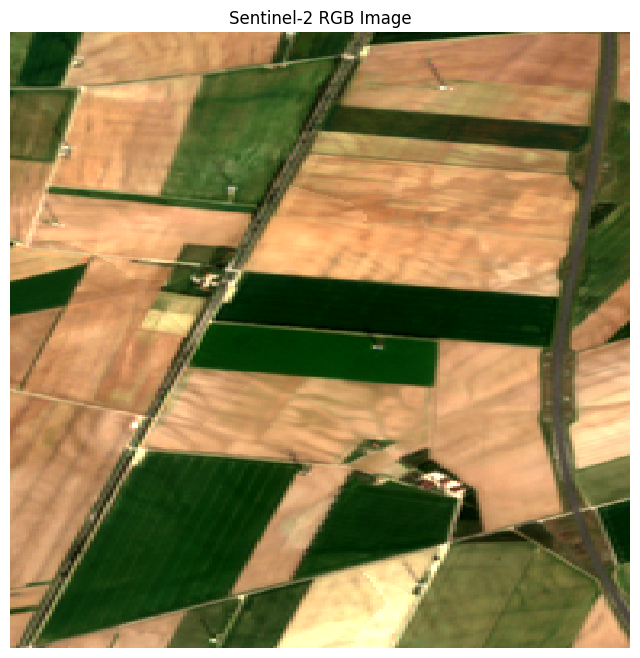

In [13]:
plt.figure(figsize=(8, 8))
img.sel(band=[3, 2, 1]).plot.imshow(robust=True)
plt.title("Sentinel-2 RGB Image")
plt.axis("off")
plt.show()